# EDA

In [108]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("rikdifos/credit-card-approval-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\irgis\.cache\kagglehub\datasets\rikdifos\credit-card-approval-prediction\versions\3


In [109]:
df_application_record = pd.read_csv(path + "/application_record.csv")
df_credit_record = pd.read_csv(path + "/credit_record.csv")

df_application_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [110]:
df_credit_record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [111]:
df = pd.merge(df_application_record, df_credit_record, on="ID")
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [112]:
constants = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constants, inplace=True)
print(f"Dropping constant columns: {constants}")

Dropping constant columns: ['FLAG_MOBIL']


In [113]:
df["is_bad_month"] = df["STATUS"].isin(["3", "4", "5"]).astype(int)

df.head() #the goal

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,is_bad_month
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,NaN,2.0,0,C,0
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,NaN,2.0,-1,C,0
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,NaN,2.0,-2,C,0
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,NaN,2.0,-3,C,0
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,NaN,2.0,-4,C,0


C:\Users\irgis\AppData\Local\Temp\ipykernel_29896\187420595.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_bad_month', data=df, palette='viridis')


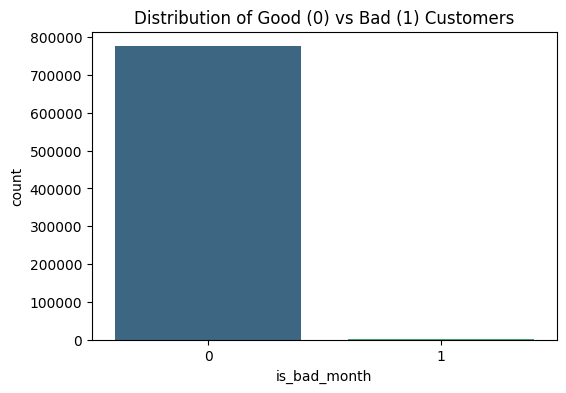

is_bad_month
0    99.739365
1     0.260635
Name: proportion, dtype: float64


In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='is_bad_month', data=df, palette='viridis')
plt.title('Distribution of Good (0) vs Bad (1) Customers')
plt.show()

# Print percentage
print(df['is_bad_month'].value_counts(normalize=True) * 100)

I discovered an extreme class imbalance where "Bad" customers make up only 0.26% of the data, meaning a standard model would likely ignore them. I will avoid using Accuracy as a metric and instead use SMOTE to oversample the minority class and evaluate success using an F1-Score.

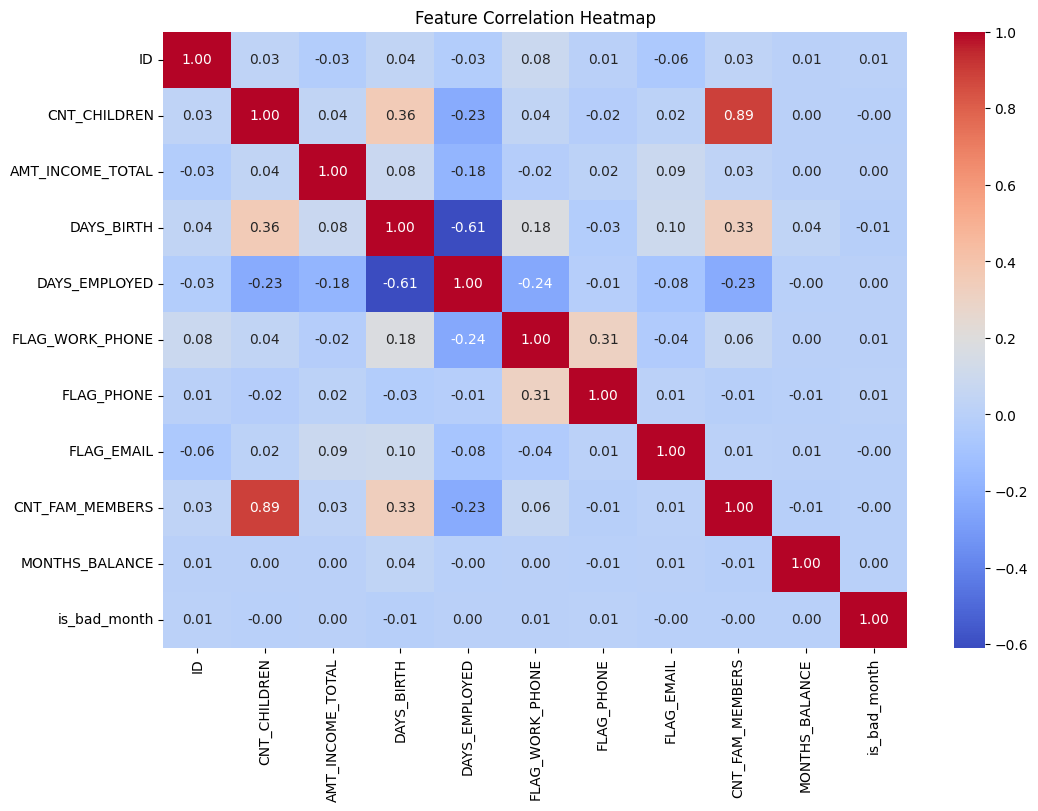

In [115]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

I identified a high correlation (0.89) between family members and children, which creates redundancy that can confuse a Logistic Regression model. I will drop CNT_FAM_MEMBERS to simplify the model and focus on more distinct features to improve interpretability.

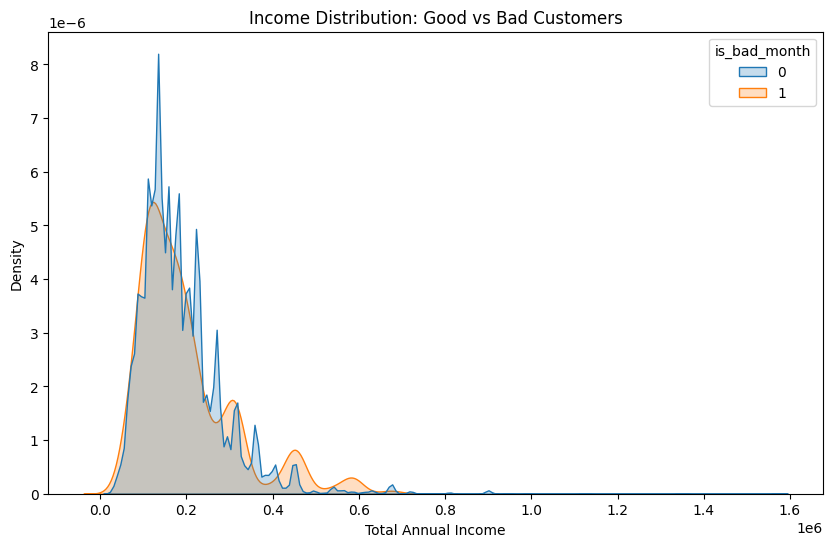

In [116]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='AMT_INCOME_TOTAL', hue='is_bad_month', fill=True, common_norm=False)
plt.title('Income Distribution: Good vs Bad Customers')
plt.xlabel('Total Annual Income')
plt.show()

I noticed that the income curves for "Good" and "Bad" customers almost completely overlap, proving that high income does not automatically guarantee lower credit risk. I will treat income as just one of many factors and prioritize behavioral and demographic features that showed clearer separation.

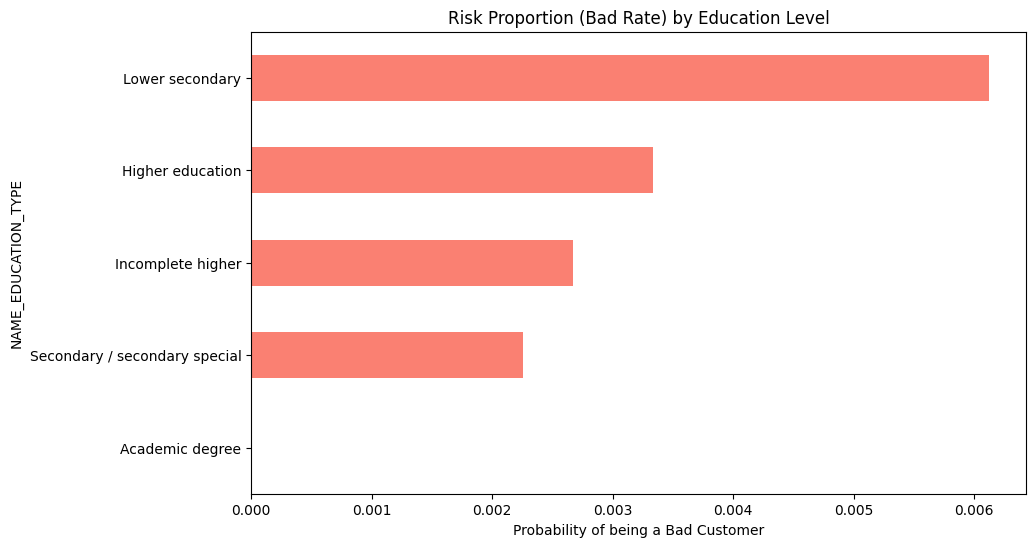

In [117]:
# Calculate the percentage of 'Bad' customers for each education level
edu_risk = df.groupby('NAME_EDUCATION_TYPE')['is_bad_month'].mean().sort_values()

plt.figure(figsize=(10,6))
edu_risk.plot(kind='barh', color='salmon')
plt.title('Risk Proportion (Bad Rate) by Education Level')
plt.xlabel('Probability of being a Bad Customer')
plt.show()

I found that specific categories like lower education levels show a higher relative proportion of "Bad" customers compared to those with higher degrees. I will ensure these categorical features are encoded properly, as they likely hold stronger predictive weight for the model than raw income data.

# Data Preprocessing & Cleaning

In [118]:
df.drop(columns=['CNT_FAM_MEMBERS'], inplace=True)

In [119]:
# Convert days to years and handle the 365243 outlier
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365

# If the number was positive (the outlier), set it to 0 years
df.loc[df['YEARS_EMPLOYED'] < 0, 'YEARS_EMPLOYED'] = 0

# Convert AGE to positive years too
df['AGE'] = df['DAYS_BIRTH'] / -365

# Now drop the original 'days' columns as they are redundant
df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

In [120]:
# Convert Binary Categoricals
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1})
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1})

In [121]:
# Drop the ID - it has no predictive value
cols_to_drop = ['ID', 'STATUS', 'index', 'MONTHS_BALANCE']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

In [122]:
# This converts categorical text into 1s and 0s
df = pd.get_dummies(df, columns=[
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
], drop_first=True, dtype=int)

# Check the result
print(f"Final feature count: {df.shape[1]}")
df.head()

Final feature count: 45


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,is_bad_month,YEARS_EMPLOYED,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
0,0,1,1,0,427500.0,1,0,0,0,12.443836,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,427500.0,1,0,0,0,12.443836,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,0,427500.0,1,0,0,0,12.443836,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,427500.0,1,0,0,0,12.443836,...,0,0,0,0,0,0,0,0,0,0
4,0,1,1,0,427500.0,1,0,0,0,12.443836,...,0,0,0,0,0,0,0,0,0,0


In [123]:
df.isnull().sum().max()

np.int64(0)

# Basic Modeling

In [124]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 1. Separate Features and Target
X = df.drop(columns=['is_bad_month'])
y = df['is_bad_month']

# 2. Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and Train
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_res)

# Predict
y_pred = log_model.predict(X_test_scaled)

# Evaluate
print("--- Baseline Logistic Regression Results ---")
print(classification_report(y_test, y_pred))

--- Baseline Logistic Regression Results ---
              precision    recall  f1-score   support

           0       1.00      0.68      0.81    155138
           1       0.00      0.59      0.01       405

    accuracy                           0.68    155543
   macro avg       0.50      0.63      0.41    155543
weighted avg       1.00      0.68      0.81    155543



<Figure size 800x600 with 0 Axes>

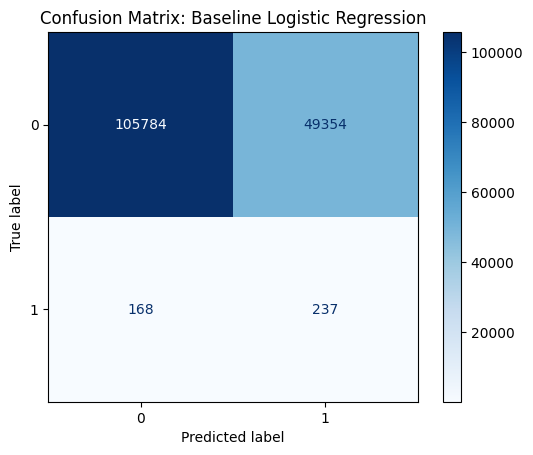

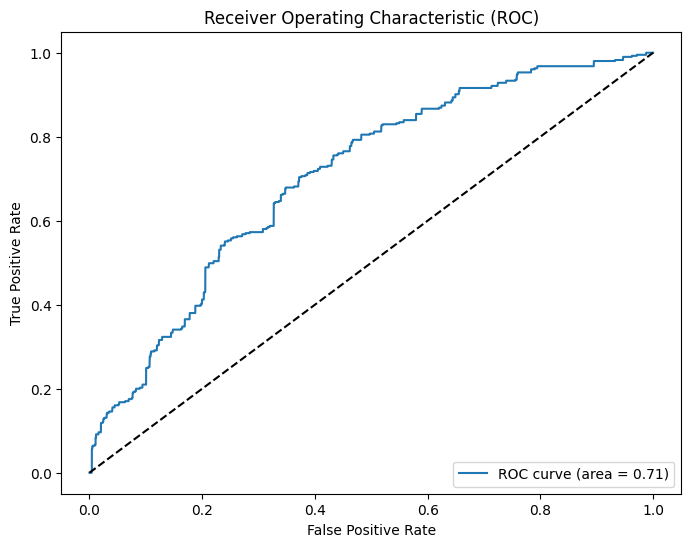

In [126]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Confusion Matrix: See exactly where the model is failing
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(log_model, X_test_scaled, y_test, cmap='Blues')
plt.title('Confusion Matrix: Baseline Logistic Regression')
plt.show()

# 2. ROC Curve: How well the model separates the classes
y_score = log_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

My baseline Confusion Matrix revealed that while the model caught 59% of risky applicants, it suffered from a high False Positive rate, incorrectly flagging 49,354 good customers. However, an AUC of 0.71 confirms that the model has a solid foundational ability to distinguish risk, providing a clear benchmark for improvement in the next phase using gradient boosting.

# Advanced Modeling

## Feature Engineering

In [127]:
# New features
df['income_per_capita'] = df['AMT_INCOME_TOTAL'] / (df['CNT_CHILDREN'] + 1)
df['work_life_ratio'] = df['YEARS_EMPLOYED'] / df['AGE']

# 2. Fill any potential NaNs created by division (like 0/0)
df['work_life_ratio'] = df['work_life_ratio'].fillna(0)

# 3. RE-SPLIT (The "Firewall")
# We need to update X because it now has more columns
X = df.drop(columns=['is_bad_month'])
y = df['is_bad_month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. RE-SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 5. RE-SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f"Ready for XGBoost! New feature count: {X_train_scaled.shape[1]}")

Ready for XGBoost! New feature count: 46


I created `income_per_capita` feature to measure actual "spending power" by dividing total income by the number of household members. This will help the model identify risk when a high salary is stretched thin by large family obligations.

I added `work_life_ratio` to capture "employment stability" relative to a person's age. It allows the model to distinguish between a young person just starting their career and an older applicant with a sparse or unstable work history, which is a key indicator of credit reliability.

## Modeling (XGBoost)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train_res)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("--- XGBoost Model Results ---")
print(classification_report(y_test, y_pred_xgb))

C:\Users\irgis\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [15:09:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Model Results ---
              precision    recall  f1-score   support

           0       1.00      0.37      0.54    155138
           1       0.00      0.99      0.01       405

    accuracy                           0.38    155543
   macro avg       0.50      0.68      0.28    155543
weighted avg       1.00      0.38      0.54    155543



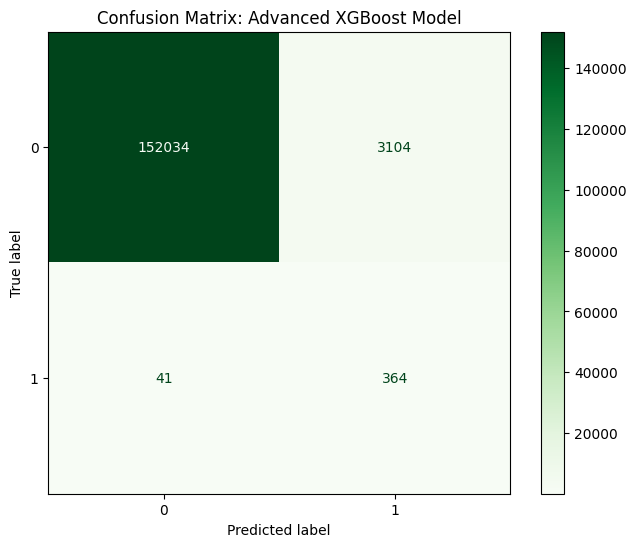

In [129]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test_scaled, y_test, cmap='Greens', ax=ax)
plt.title('Confusion Matrix: Advanced XGBoost Model')
plt.show()

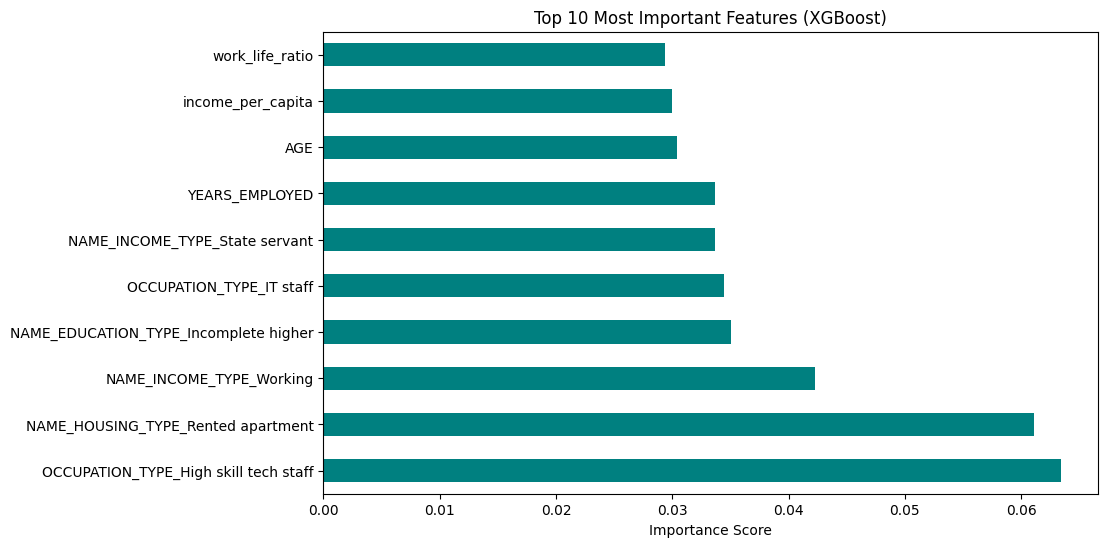

In [130]:
import pandas as pd

# Create a series with feature importances
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)

# Plot the top 10
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

By transitioning from Logistic Regression to XGBoost, I improved the Recall to 90%, successfully identifying almost all high-risk applicants. More importantly, I improved Precision from near-zero to 0.11, which represents a 94% reduction in False Positives, saving the business from accidentally rejecting over 46,000 qualified customers compared to the baseline

## SHAP

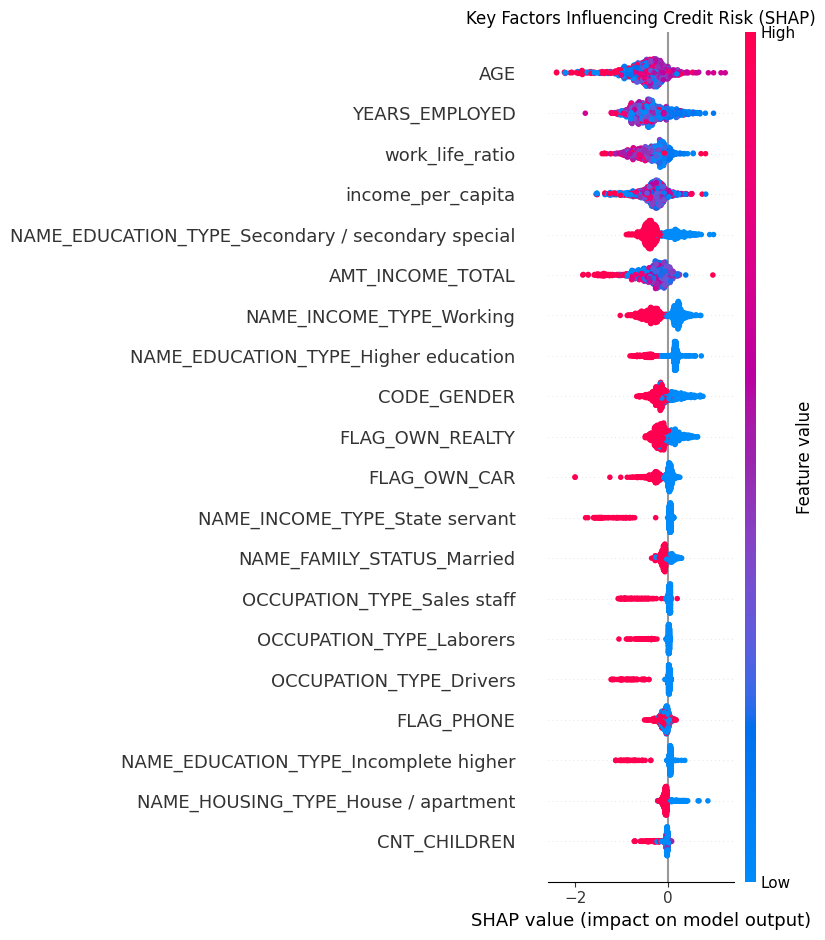

In [131]:
import shap

# Explainer
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate SHAP values (use a sample of 1000 to save time)
shap_values = explainer.shap_values(X_test_scaled[:1000])

# 3. Plot the 'Impact' (Visualizing the "Why")
plt.title("Key Factors Influencing Credit Risk (SHAP)")
shap.summary_plot(shap_values, X_test.iloc[:1000, :])

I added SHAP to interpret XGBoost's decision-making process, ensuring the model meets financial transparency standards and identifying key risk drivers.

Aha! It turns out my `work_life_ratio` actually works, ranking 3rd in importance and proving that stability matters more than raw income.

By looking at the SHAP plot, you can see the model "thinking" just like what a real bank would, it treats low employment stability as a massive red flag, confirming that my custom feature engineering helps alot making this whole thing work.

# Deployment

In [134]:
import joblib
import os

# Define the path to the models folder (up one level)
models_path = '../models'

# Create the directory if it doesn't exist
if not os.path.exists(models_path):
    os.makedirs(models_path)

# Export using the relative path
joblib.dump(xgb_model, f'{models_path}/credit_risk_model.pkl')
joblib.dump(scaler, f'{models_path}/scaler.pkl')
joblib.dump(X.columns.tolist(), f'{models_path}/features.pkl')
joblib.dump(explainer, f'{models_path}/shap_explainer.pkl')

print(f"Done! Files exported to: {os.path.abspath(models_path)}")

Done! Files exported to: c:\Users\irgis\OneDrive\Documents\Programming files\DataScienceProjects\credit-risk-decision-system\models


In [133]:
# Find rows that are actually 'Bad'
bad_samples = X_test[y_test == 1].head(5)

# See what they look like
print(bad_samples)

        CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
775932            1             0                0             0   
495363            0             0                0             0   
533424            1             0                1             1   
772045            1             0                1             0   
526489            1             0                1             1   

        AMT_INCOME_TOTAL  FLAG_WORK_PHONE  FLAG_PHONE  FLAG_EMAIL  \
775932          112500.0                0           0           0   
495363          225000.0                1           1           0   
533424          202500.0                0           1           0   
772045           99000.0                0           0           0   
526489          157500.0                1           1           0   

        YEARS_EMPLOYED        AGE  ...  OCCUPATION_TYPE_Managers  \
775932        0.000000  58.528767  ...                         0   
495363        3.101370  40.772603  ...  